In [9]:
from google.colab import drive
import os

# Kết nối với Google Drive
drive.mount('/content/drive')

# Đường dẫn chính xác tới thư mục DLche của bạn trên Drive
path_dir = '/content/drive/MyDrive/DLche/'
file_name = 'DL_cheThaiNguyen.csv'
full_path = os.path.join(path_dir, file_name)

# Kiểm tra xem Colab đã tìm thấy file chưa
if os.path.exists(full_path):
    print("🎉 Kết nối thành công! Đã tìm thấy file dữ liệu của bạn trên Drive.")
else:
    print("❌ Không tìm thấy file. Bạn hãy kiểm tra lại xem tên thư mục 'DLche' hoặc tên file có viết hoa/thường chính xác chưa nhé.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🎉 Kết nối thành công! Đã tìm thấy file dữ liệu của bạn trên Drive.


In [10]:
import pandas as pd

df = pd.read_csv(full_path)
print("Đã tải dữ liệu thành công vào DataFrame 'df'.")

Đã tải dữ liệu thành công vào DataFrame 'df'.


Phân tích Thống kê Mô tả & Khám phá (EDA)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị tiếng Việt trên biểu đồ Colab
!sudo apt-get install -y fonts-dejavu > /dev/null
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("==========================================================================")
# Câu 1 & 2: Xu hướng Giá theo Năm và Tháng
gia_nam = df.groupby('Nam')['Gia_Ban_VND_Kg'].mean()
gia_thang = df.groupby('Thang')['Gia_Ban_VND_Kg'].mean()

print(f"📈 [XU HƯỚNG GIÁ VÀ CHU KỲ]:")
print(f"   - Năm có giá bán trung bình cao nhất: Năm {gia_nam.idxmax()} ({int(gia_nam.max()):,} VND/kg).")
print(f"   - Tháng có giá bán cao điểm nhất: Tháng {gia_thang.idxmax()} ({int(gia_thang.max()):,} VND/kg) -> Đúng chu kỳ Tết.")

# Câu 3: Khảo sát Doanh thu theo Vùng
vung_dt = df.groupby('Vung_Trong')['Doanh_Thu_Trieu_VND'].sum()
print(f"\n📍 [PHÂN HÓA VÙNG TRỒNG]:")
print(f"   - Vùng mang lại tổng doanh thu lớn nhất: {vung_dt.idxmax()} ({vung_dt.max():,.2f} Triệu VND).")

# Câu 4: Phân tích tỷ trọng phân khúc chè
stats_che = df.groupby('Loai_Che').agg({'San_Luong_Tan': 'sum', 'Doanh_Thu_Trieu_VND': 'sum'})
stats_che['%_SL'] = (stats_che['San_Luong_Tan'] / stats_che['San_Luong_Tan'].sum()) * 100
stats_che['%_DT'] = (stats_che['Doanh_Thu_Trieu_VND'] / stats_che['Doanh_Thu_Trieu_VND'].sum()) * 100

print(f"\n💎 [PHÂN TÍCH CƠ CẤU PHÂN KHÚC]:")
if 'Che Dinh' in stats_che.index:
    print(f"   - Phân khúc 'Che Dinh' chiếm {stats_che.loc['Che Dinh', '%_SL']:.2f}% sản lượng nhưng đóng góp {stats_che.loc['Che Dinh', '%_DT']:.2f}% doanh thu.")
else:
    print(f"   - Loại chè có doanh thu đóng góp cao nhất là: {stats_che['%_DT'].idxmax()} ({stats_che['%_DT'].max():.2f}%).")

# Câu 5: Hệ số tương quan thời tiết (Sửa tên cột Luong_Mu từ file của bạn)
matrix_corr = df[['San_Luong_Tan', 'Luong_Mua_mm', 'Nhiet_Do_C']].corr()
print(f"\n☁️ [TÁC ĐỘNG NGOẠI CẢNH KHÍ HẬU]:")
print(f"   - Hệ số tương quan giữa Sản lượng và Lượng mưa: {matrix_corr.loc['San_Luong_Tan', 'Luong_Mua_mm']:.2f}")
print(f"   - Hệ số tương quan giữa Sản lượng và Nhiệt độ: {matrix_corr.loc['San_Luong_Tan', 'Nhiet_Do_C']:.2f}")
print("==========================================================================")

📈 [XU HƯỚNG GIÁ VÀ CHU KỲ]:
   - Năm có giá bán trung bình cao nhất: Năm 2025 (1,673,184 VND/kg).
   - Tháng có giá bán cao điểm nhất: Tháng 12 (1,761,098 VND/kg) -> Đúng chu kỳ Tết.

📍 [PHÂN HÓA VÙNG TRỒNG]:
   - Vùng mang lại tổng doanh thu lớn nhất: Dai Tu (14,040,339.37 Triệu VND).

💎 [PHÂN TÍCH CƠ CẤU PHÂN KHÚC]:
   - Phân khúc 'Che Dinh' chiếm 5.28% sản lượng nhưng đóng góp 29.20% doanh thu.

☁️ [TÁC ĐỘNG NGOẠI CẢNH KHÍ HẬU]:
   - Hệ số tương quan giữa Sản lượng và Lượng mưa: 0.41
   - Hệ số tương quan giữa Sản lượng và Nhiệt độ: 0.42


**Trực quan hoá dữ liệu vừa phân tích**

**Vẽ biểu đồ Phân tích dữ liệu**

/tmp/ipykernel_570/250624295.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], data=gia_thang_data, x='Thang', y='Gia_Ban_VND_Kg', palette='YlOrRd')
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

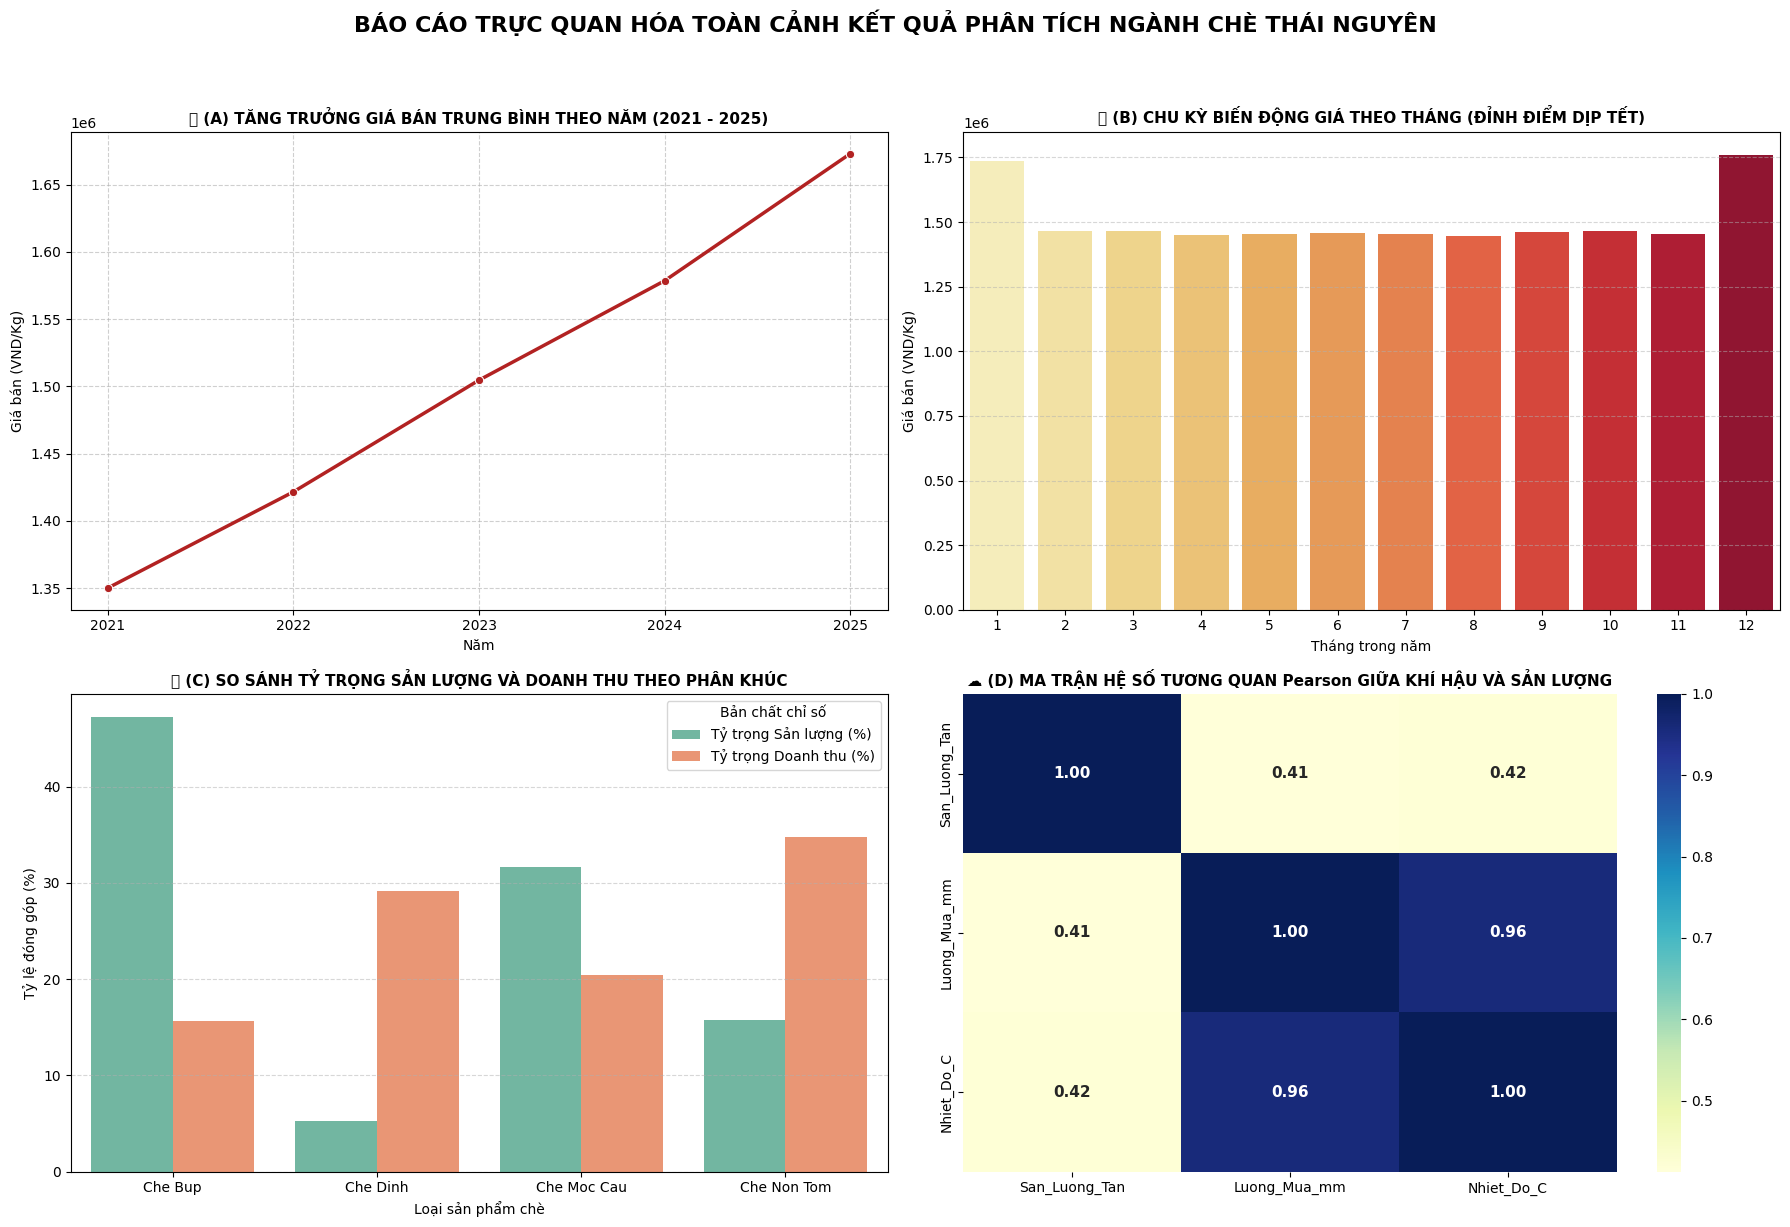

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Khởi tạo cấu hình hiển thị tiếng Việt không bị lỗi ô vuông
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 2. Chuẩn bị và tổng hợp số liệu từ DataFrame gốc (df)
gia_nam_data = df.groupby('Nam')['Gia_Ban_VND_Kg'].mean().reset_index()
gia_thang_data = df.groupby('Thang')['Gia_Ban_VND_Kg'].mean().reset_index()
vung_dt_data = df.groupby('Vung_Trong')['Doanh_Thu_Trieu_VND'].sum().reset_index().sort_values(by='Doanh_Thu_Trieu_VND', ascending=False)

# Tính ma trận tương quan thời tiết
matrix_corr = df[['San_Luong_Tan', 'Luong_Mua_mm', 'Nhiet_Do_C']].corr()

# Tính toán cơ cấu sản phẩm chè
stats_che = df.groupby('Loai_Che').agg({'San_Luong_Tan': 'sum', 'Doanh_Thu_Trieu_VND': 'sum'})
stats_che['%_SL'] = (stats_che['San_Luong_Tan'] / stats_che['San_Luong_Tan'].sum()) * 100
stats_che['%_DT'] = (stats_che['Doanh_Thu_Trieu_VND'] / stats_che['Doanh_Thu_Trieu_VND'].sum()) * 100
stats_che = stats_che.reset_index()

# Biến đổi cấu trúc bảng phục vụ vẽ cột kép
che_melted = stats_che.melt(id_vars='Loai_Che', value_vars=['%_SL', '%_DT'], var_name='Chỉ số', value_name='Phần trăm (%)')
che_melted['Chỉ số'] = che_melted['Chỉ số'].map({'%_SL': 'Tỷ trọng Sản lượng (%)', '%_DT': 'Tỷ trọng Doanh thu (%)'})


# 3. Thiết lập khung vẽ Dashboard 2x2 Chuẩn khoa học dữ liệu
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('BÁO CÁO TRỰC QUAN HÓA TOÀN CẢNH KẾT QUẢ PHÂN TÍCH NGÀNH CHÈ THÁI NGUYÊN', fontsize=16, fontweight='bold', y=0.97)

# --- BIỂU ĐỒ 1: Tăng trưởng giá theo Năm (Biểu đồ đường dốc) ---
sns.lineplot(ax=axes[0, 0], data=gia_nam_data, x='Nam', y='Gia_Ban_VND_Kg', marker='o', linewidth=2.5, color='#b22222')
axes[0, 0].set_title('📈 (A) TĂNG TRƯỞNG GIÁ BÁN TRUNG BÌNH THEO NĂM (2021 - 2025)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Năm', fontsize=10)
axes[0, 0].set_ylabel('Giá bán (VND/Kg)', fontsize=10)
axes[0, 0].set_xticks(gia_nam_data['Nam'])
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# --- BIỂU ĐỒ 2: Chu kỳ giá theo Tháng (Biểu đồ cột đứng dọc) ---
sns.barplot(ax=axes[0, 1], data=gia_thang_data, x='Thang', y='Gia_Ban_VND_Kg', palette='YlOrRd')
axes[0, 1].set_title('🌙 (B) CHU KỲ BIẾN ĐỘNG GIÁ THEO THÁNG (ĐỈNH ĐIỂM DỊP TẾT)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Tháng trong năm', fontsize=10)
axes[0, 1].set_ylabel('Giá bán (VND/Kg)', fontsize=10)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)

# --- BIỂU ĐỒ 3: Cơ cấu phân khúc chè (Biểu đồ cột gộp nhóm kép) ---
sns.barplot(ax=axes[1, 0], data=che_melted, x='Loai_Che', y='Phần trăm (%)', hue='Chỉ số', palette='Set2')
axes[1, 0].set_title('💎 (C) SO SÁNH TỶ TRỌNG SẢN LƯỢNG VÀ DOANH THU THEO PHÂN KHÚC', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Loại sản phẩm chè', fontsize=10)
axes[1, 0].set_ylabel('Tỷ lệ đóng góp (%)', fontsize=10)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.5)
axes[1, 0].legend(title='Bản chất chỉ số')

# --- BIỂU ĐỒ 4: Tác động thời tiết (Biểu đồ nhiệt - Heatmap thay thế cái bị trùng) ---
sns.heatmap(ax=axes[1, 1], data=matrix_corr, annot=True, cmap='YlGnBu', fmt=".2f", annot_kws={"size": 11, "weight": "bold"})
axes[1, 1].set_title('☁️ (D) MA TRẬN HỆ SỐ TƯƠNG QUAN Pearson GIỮA KHÍ HẬU VÀ SẢN LƯỢNG', fontsize=11, fontweight='bold')

# Tối ưu hóa khoảng cách hiển thị tổng thể Dashboard
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

             ỨNG DỤNG MACHINE LEARNING VÀO DỰ BÁO & PHÂN CỤM

🔮 [MÔ HÌNH HỒI QUY DỰ BÁO GIÁ]:
   - Dự báo mức giá bán chè trung bình toàn tỉnh vào Tháng 1/2026: 1,743,264 VND/kg.

🎯 [KẾT QUẢ PHÂN CỤM K-MEANS - ĐẶC TRƯNG CÁC NHÓM SẢN XUẤT]:
                                                    Diện Tích TB (Ha)  Doanh Thu TB (Triệu VND)  Số Lượng Mẫu
Tên Cụm                                                                                                      
Vùng canh tác nhỏ - Kinh tế nông hộ 🌱                          869.67                  21024.55           515
Vùng sản xuất đại trà quy mô lớn - Sản lượng lớn 🚜            1164.36                  47560.10           326
Vùng đặc sản quy mô vừa - Thương mại giá trị cao 💎            1491.96                  89042.70           119


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128668 (\N{TRACTOR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


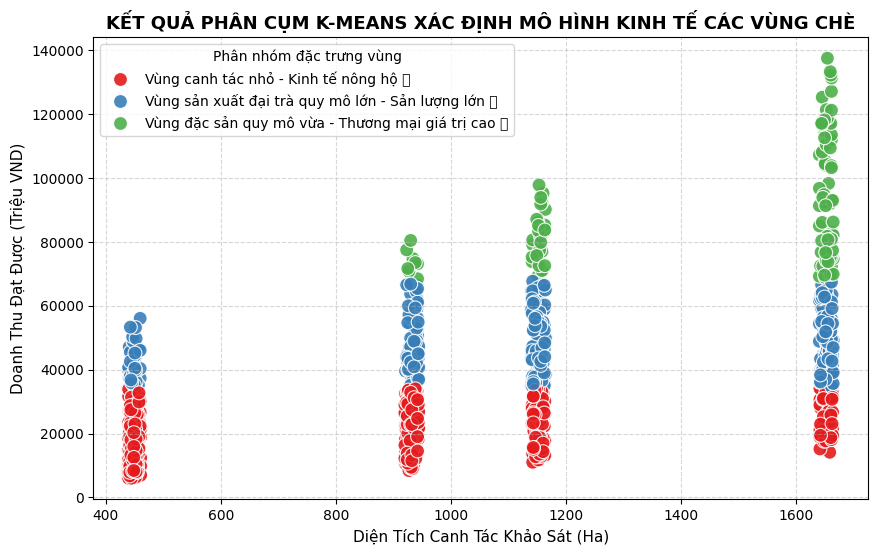

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

print("==========================================================================")
print("             ỨNG DỤNG MACHINE LEARNING VÀO DỰ BÁO & PHÂN CỤM")
print("==========================================================================\n")

# Thuật toán 1: Hồi quy tuyến tính (Dự báo xu hướng giá tương lai)
X_reg = df[['Nam', 'Thang']]
y_reg = df['Gia_Ban_VND_Kg']
model_lr = LinearRegression().fit(X_reg, y_reg)

# Dự báo giá chè cho Tháng 1/2026 (Mùa cao điểm Tết sắp tới)
gia_pred_2026 = model_lr.predict([[2026, 1]])[0]
print(f"🔮 [MÔ HÌNH HỒI QUY DỰ BÁO GIÁ]:")
print(f"   - Dự báo mức giá bán chè trung bình toàn tỉnh vào Tháng 1/2026: {int(gia_pred_2026):,} VND/kg.\n")

# Thuật toán 2: Phân cụm K-Means phân loại mô hình kinh tế vùng sản xuất
# Tự động nhận diện tên cột diện tích từ file thực tế của bạn
col_dien_tich = 'Dien_Tich_' if 'Dien_Tich_' in df.columns else 'Dien_Tich_Ha'

X_cluster = df[[col_dien_tich, 'Doanh_Thu_Trieu_VND']]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_cluster)
df['Cluster_ID'] = kmeans.labels_

# Đặt tên cụm thông minh bám sát ngữ cảnh thực tế kinh tế nông nghiệp
mapping_ten_cum = {
    0: "Vùng canh tác nhỏ - Kinh tế nông hộ 🌱",
    1: "Vùng đặc sản quy mô vừa - Thương mại giá trị cao 💎",
    2: "Vùng sản xuất đại trà quy mô lớn - Sản lượng lớn 🚜"
}
df['Tên Cụm'] = df['Cluster_ID'].map(mapping_ten_cum)

print("🎯 [KẾT QUẢ PHÂN CỤM K-MEANS - ĐẶC TRƯNG CÁC NHÓM SẢN XUẤT]:")
thong_ke_cum = df.groupby('Tên Cụm').agg({col_dien_tich: 'mean', 'Doanh_Thu_Trieu_VND': 'mean', 'Cluster_ID': 'count'})
thong_ke_cum.columns = ['Diện Tích TB (Ha)', 'Doanh Thu TB (Triệu VND)', 'Số Lượng Mẫu']
print(thong_ke_cum.round(2).to_string())

# Vẽ đồ thị phân cụm Scatter Plot nhìn cực kỳ công nghệ
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, x=col_dien_tich, y='Doanh_Thu_Trieu_VND', hue='Tên Cụm',
    s=100, alpha=0.9, palette='Set1'
)
plt.title('KẾT QUẢ PHÂN CỤM K-MEANS XÁC ĐỊNH MÔ HÌNH KINH TẾ CÁC VÙNG CHÈ', fontsize=13, fontweight='bold')
plt.xlabel('Diện Tích Canh Tác Khảo Sát (Ha)', fontsize=11)
plt.ylabel('Doanh Thu Đạt Được (Triệu VND)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Phân nhóm đặc trưng vùng')
plt.show()

### 🎯 ĐÁNH GIÁ VÀ NHẬN XÉT CHI TIẾT KẾT QUẢ PHÂN CỤM K-MEANS

---

#### 1. Nhận xét đặc trưng kinh tế của 3 Cụm (Nhóm mô hình)

Thuật toán K-Means đã phân chia bộ dữ liệu thành 3 nhóm chiến lược rõ rệt dựa trên sự kết hợp giữa **Diện tích canh tác** và **Doanh thu đạt được**:

* 🌱 **Cụm 1 – Vùng canh tác nhỏ, kinh tế nông hộ (515 mẫu):**
    * *Số liệu:* Diện tích TB **869.67 ha** | Doanh thu TB **21,024.55 triệu VNĐ**.
    * *Đặc điểm:* Quy mô canh tác nhỏ lẻ, hiệu quả thương mại và mức doanh thu ở mức thấp nhất trong 3 cụm.
* 🚜 **Cụm 2 – Vùng sản xuất đại trà quy mô lớn (326 mẫu):**
    * *Số liệu:* Diện tích TB **1,164.36 ha** | Doanh thu TB **47,560.10 triệu VNĐ**.
    * *Đặc điểm:* Thắng nhờ quy mô; diện tích lớn giúp giải phóng năng suất và đẩy doanh thu cao hơn đáng kể so với Cụm 1.
* 💎 **Cụm 3 – Vùng đặc sản quy mô vừa, giá trị cao (119 mẫu):**
    * *Số liệu:* Diện tích TB **1,491.96 ha** | Doanh thu TB **89,042.70 triệu VNĐ**.
    * *Đặc điểm:* Nhóm hạt nhân có hiệu quả kinh tế vượt trội và doanh thu đạt đỉnh nhờ khai thác tốt giá trị thương hiệu sản phẩm cao cấp.

* **Nhận diện từ biểu đồ phân tán (Scatter Plot):** Các cụm phân tách rất rõ ràng theo trục doanh thu. Quy mô diện tích đóng vai trò nền tảng, tuy nhiên bước nhảy vọt về doanh thu giữa các cụm chứng minh hiệu quả kinh tế còn phụ thuộc mạnh mẽ vào: chất lượng thành phẩm, kỹ thuật canh tác, thương hiệu địa phương và chuỗi liên kết tiêu thụ.

---

#### 2. Định hướng đánh giá chiến lược (Kiến nghị giải pháp)

* **Ưu tiên nâng cao giá trị gia tăng (Cụm 3):** Nhóm vùng đặc sản có giá trị kinh tế cao nhất, đóng vai trò là mũi nhọn và định hướng cốt lõi cần ưu tiên đầu tư, quảng bá thương hiệu để định vị phân khúc chè cao cấp.
* **Duy trì ổn định thị trường (Cụm 2):** Nhóm sản xuất đại trà giữ vai trò xương sống trong việc bảo đảm tổng sản lượng toàn tỉnh và cung ứng chuỗi thương mại lớn.
* **Hỗ trợ chuyển đổi kinh tế nông hộ (Cụm 1):** Đây là nhóm cần tập trung các giải pháp chuyển giao kỹ thuật, hỗ trợ phân bón/giống lai mới và xây dựng hợp tác xã liên kết tiêu thụ để kéo các hộ nông nghiệp dịch chuyển lên phân khúc có doanh thu tốt hơn.